# Black-Litterman Base Model (Member 1)
FX / Gold / Oil universe. **Baseline optimizer only **

Existing model = **PyPortfolioOpt** (all BL math). Our code = data prep, prior, interface, backtest.

> Note: dataset file expected as `project8_dataset_v2.csv` in the same folder.

In [1]:
# install the existing model library (run once)
!pip install --quiet --break-system-packages pyportfolioopt

In [2]:
import numpy as np
import pandas as pd
from pypfopt import risk_models, EfficientFrontier
from pypfopt.black_litterman import BlackLittermanModel

In [3]:
# --- Load data: keep only the 4 asset close prices ---
df = pd.read_csv("project8_dataset_v2.csv", parse_dates=["Date"], index_col="Date")

assets = ["EURUSD", "GBPUSD", "GOLD", "OIL"]
prices = df[[f"{a}_Close" for a in assets]].copy()
prices.columns = assets
prices = prices.dropna()

print("Prices shape:", prices.shape)
prices.tail(3).round(4)

Prices shape: (2132, 4)


,EURUSD,GBPUSD,GOLD,OIL
Date,,,,
2026-06-25,1.1354,1.3167,4030.5,71.92
2026-06-26,1.1362,1.3188,4078.7,69.23
2026-06-29,1.1386,1.3197,4022.3,70.75


In [4]:
# --- Returns + April-2020 fix ---
# WTI oil went negative on 2020-04-20 (-$37.63). pct_change through a
# negative price gives meaningless returns (-306%, +127%) that inflate the
# covariance ~10x. Standard treatment: winsorize (cap) daily returns at +/-20%.

returns = prices.pct_change().dropna()
returns_clean = returns.clip(lower=-0.20, upper=0.20)

print("Days clipped per asset:")
print((returns.abs() > 0.20).sum())
print("\nAnnualized vol  before / after fix:")
print(pd.DataFrame({
    "before": returns.std() * np.sqrt(252),
    "after":  returns_clean.std() * np.sqrt(252),
}).round(3))

Days clipped per asset:
EURUSD     0
GBPUSD     0
GOLD       0
OIL       11
dtype: int64

Annualized vol  before / after fix:
        before  after
EURUSD   0.073  0.073
GBPUSD   0.088  0.088
GOLD     0.173  0.173
OIL      1.238  0.466


In [5]:
# --- Covariance (Ledoit-Wolf) + equal-weight implied prior, TRAIN only ---
# TRAIN-only estimation avoids look-ahead into the TEST period.
train_dates = df[df["PERIOD"] == "TRAIN"].index
train_rets  = returns_clean.loc[returns_clean.index.isin(train_dates)]
print("Train return rows:", len(train_rets))

# returns_data=True: tell the library these are returns, not prices
S = risk_models.CovarianceShrinkage(train_rets, returns_data=True).ledoit_wolf()

# No market caps in FX/commodities -> equal-weight implied prior: pi = delta * S * w_eq
delta = 2.5
w_eq  = np.ones(len(assets)) / len(assets)
pi    = pd.Series(delta * S.values @ w_eq, index=assets)

print("\nPrior (equilibrium) returns:")
print(pi.round(4))

Train return rows: 1758

Prior (equilibrium) returns:
EURUSD    0.0066
GBPUSD    0.0084
GOLD      0.0203
OIL       0.1391
dtype: float64


In [6]:
# --- Black-Litterman baseline: NO views -> posterior == prior ---
bl_base  = BlackLittermanModel(S, pi=pi, absolute_views={})
ret_base = bl_base.bl_returns()
cov_base = bl_base.bl_cov()

ef = EfficientFrontier(ret_base, cov_base, weight_bounds=(0, 1))
ef.max_quadratic_utility(risk_aversion=delta)
w_base = pd.Series(ef.clean_weights())

print("Baseline weights (no views):")
print(w_base.round(3))

Baseline weights (no views):
EURUSD    0.267
GBPUSD    0.248
GOLD      0.246
OIL       0.239
dtype: float64


In [7]:
# --- Team interface: every other layer calls ONLY this function ---
def run_bl(views: dict = {}, confidences: list | None = None):
    """views: {"ASSET": expected_return}, confidences: [0-1] per view.
    Empty views -> baseline. Returns (posterior returns, cov, weights)."""
    if views and confidences:
        bl = BlackLittermanModel(S, pi=pi, absolute_views=views,
                                 view_confidences=confidences, omega="idzorek")
    else:
        bl = BlackLittermanModel(S, pi=pi, absolute_views=views)
    ret, cov = bl.bl_returns(), bl.bl_cov()
    ef = EfficientFrontier(ret, cov, weight_bounds=(0, 1))
    ef.max_quadratic_utility(risk_aversion=delta)
    return ret, cov, pd.Series(ef.clean_weights())

# sanity checks
r, cov, w = run_bl()
assert abs(w.sum() - 1) < 1e-6, "weights must sum to 1"
assert (w >= -1e-9).all(),      "long-only violated"
print("All sanity checks PASSED")
print("Interface ready:  run_bl(views, confidences) -> (returns, cov, weights)")

All sanity checks PASSED
Interface ready:  run_bl(views, confidences) -> (returns, cov, weights)


In [8]:
# --- Monthly-rebalanced backtest over the TEST period (no look-ahead) ---
test_dates = df[df["PERIOD"] == "TEST"].index
test_rets  = returns_clean.loc[returns_clean.index.isin(test_dates)]

WINDOW = 252  # trailing 1-year estimation window

# FIX: resample("ME").last() labels each bucket with the calendar month-end (e.g. 2025-05-31),
# not the actual last TRADING day in that month -- for any month where the calendar month-end
# falls on a weekend/holiday, that label never appears in test_rets.index, so the original
# `date in rebalance_dates` check silently failed to trigger for that month (only 12 of 18
# months matched). Fixed by snapping each calendar month-end target to the last real trading
# day on or before it, so every intended month actually rebalances.
month_end_targets = test_rets.resample("ME").last().index
rebalance_dates = []
for target in month_end_targets:
    available = test_rets.index[test_rets.index <= target]
    if len(available) > 0:
        rebalance_dates.append(available[-1])
rebalance_dates = pd.DatetimeIndex(sorted(set(rebalance_dates)))
print(f"{len(rebalance_dates)} rebalance dates after snapping to real trading days "
      f"(was {len(month_end_targets)} calendar month-end labels, several non-trading days)")

portfolio_rets = []
current_w = w_eq.copy()

for date in test_rets.index:
    portfolio_rets.append(current_w @ test_rets.loc[date].values)
    if date in rebalance_dates or date == test_rets.index[0]:
        hist = returns_clean.loc[:date].tail(WINDOW)
        S_t  = risk_models.CovarianceShrinkage(hist, returns_data=True).ledoit_wolf()
        pi_t = pd.Series(delta * S_t.values @ w_eq, index=assets)
        bl_t = BlackLittermanModel(S_t, pi=pi_t, absolute_views={})
        ef_t = EfficientFrontier(bl_t.bl_returns(), bl_t.bl_cov(), weight_bounds=(0, 1))
        ef_t.max_quadratic_utility(risk_aversion=delta)
        current_w = np.array(list(ef_t.clean_weights().values()))

bt = pd.Series(portfolio_rets, index=test_rets.index, name="BL_baseline")
print("Backtest days:", len(bt))


18 rebalance dates after snapping to real trading days (was 18 calendar month-end labels, several non-trading days)
Backtest days: 373


              BL_baseline  Equal_weight
ann_return         0.1278        0.1291
ann_vol            0.1300        0.1342
sharpe             0.9831        0.9615
max_drawdown      -0.1326       -0.1375


<Axes: title={'center': 'Cumulative return — TEST period'}, xlabel='Date'>

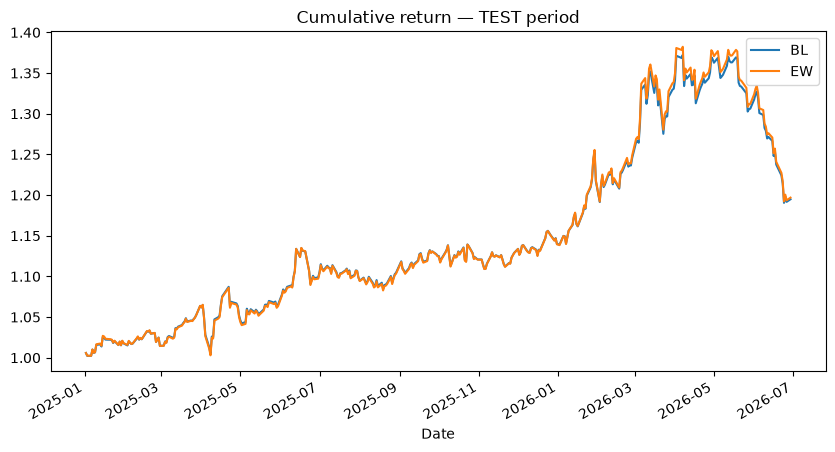

In [9]:
# --- Evaluation: metrics + cumulative-return plot ---
def metrics(r, name):
    ann_ret = (1 + r).prod() ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    cum     = (1 + r).cumprod()
    max_dd  = (cum / cum.cummax() - 1).min()
    return pd.Series({"ann_return": ann_ret, "ann_vol": ann_vol,
                      "sharpe": sharpe, "max_drawdown": max_dd}, name=name)

ew_rets = test_rets @ w_eq  # equal-weight benchmark

results = pd.concat([
    metrics(bt,      "BL_baseline"),
    metrics(ew_rets, "Equal_weight"),
], axis=1).round(4)
print(results)

(1 + pd.DataFrame({"BL": bt, "EW": ew_rets})).cumprod().plot(
    figsize=(10, 5), title="Cumulative return — TEST period")

---
## Step 5 Integration — LLM + Episodic Memory Views -> Optimized Weight Time Series

Extends the baseline above (Sections 1-9, unchanged) with the corrected Step 5 output
(`final_views_for_step5.json` — LLM views refined with episodic-memory-retrieved analogs,
covering all 19 TEST rebalance dates). Runs the exact same walk-forward engine as the baseline
backtest above, now tracking a second strategy — `BL_llm_memory` — side by side with the
existing `BL_baseline` and `Equal_weight`, and critically, **saving the actual weight vectors at
every rebalance date**, not just the resulting portfolio returns. That weight time series is the
file the Safe RL step needs as its anchor.

In [10]:
import json

with open("final_views_for_step5.json") as f:
    step5_views_raw = json.load(f)
step5_views = {pd.Timestamp(k): v for k, v in step5_views_raw.items()}
print(f"Loaded Step 5 (LLM + memory) views for {len(step5_views)} rebalance dates")

# Real Lag-Llama output (Step 3), covering all 19 rebalance dates -- added here as a third
# comparison strategy so this notebook gives ONE authoritative, fully-corrected comparison of
# every strategy built so far, rather than leaving BL_worldmodel's number stranded in an
# earlier notebook that used the same buggy date logic fixed below.
wm = pd.read_csv("lag_llama_views.csv", parse_dates=["Rebalance_Date"])
wm["Asset_clean"] = wm["Asset"].str.replace("_Close", "", regex=False)
step3_views = {}
for date, g in wm.groupby("Rebalance_Date"):
    g = g.set_index("Asset_clean").reindex(assets)
    step3_views[pd.Timestamp(date)] = {
        "views": g["Expected_Return"].to_dict(),
        "confidences": g["Confidence"].tolist(),
    }
print(f"Loaded Step 3 (world model) views for {len(step3_views)} rebalance dates")

Loaded Step 5 (LLM + memory) views for 19 rebalance dates
Loaded Step 3 (world model) views for 19 rebalance dates


### Walk-forward backtest: `BL_baseline` vs. `BL_worldmodel` vs. `BL_llm_memory` vs. `Equal_weight`

Same monthly-rebalanced, no-look-ahead loop as the baseline backtest above (same corrected
`WINDOW` and `rebalance_dates` from Section 8) -- the only thing that changes between strategies
is what gets passed to `run_bl()`. `BL_worldmodel` uses Step 3's raw forecasts alone;
`BL_llm_memory` uses Step 5's LLM-and-memory-refined views. Both reuse the exact same
`run_bl(views, confidences)` interface from Section 7 -- nothing about the team interface needed
to change for either.

In [11]:
portfolio_rets = {"BL_baseline": [], "BL_worldmodel": [], "BL_llm_memory": []}
current_w = {k: w_eq.copy() for k in portfolio_rets}
weight_log = {k: [] for k in portfolio_rets}
missing_dates = {"BL_worldmodel": [], "BL_llm_memory": []}

for date in test_rets.index:
    for name in portfolio_rets:
        portfolio_rets[name].append(current_w[name] @ test_rets.loc[date].values)

    if date in rebalance_dates or date == test_rets.index[0]:
        hist = returns_clean.loc[:date].tail(WINDOW)
        S_t  = risk_models.CovarianceShrinkage(hist, returns_data=True).ledoit_wolf()
        pi_t = pd.Series(delta * S_t.values @ w_eq, index=assets)
        globals()["S"], globals()["pi"] = S_t, pi_t   # run_bl() reads module-level S, pi

        _, _, w_b = run_bl()
        current_w["BL_baseline"] = np.array(list(w_b.reindex(assets).values))
        weight_log["BL_baseline"].append({"Date": date.date(), **dict(w_b.reindex(assets))})

        if date in step3_views:
            _, _, w_wm = run_bl(views=step3_views[date]["views"], confidences=step3_views[date]["confidences"])
        else:
            missing_dates["BL_worldmodel"].append(date)
            _, _, w_wm = run_bl()
        current_w["BL_worldmodel"] = np.array(list(w_wm.reindex(assets).values))
        weight_log["BL_worldmodel"].append({"Date": date.date(), **dict(w_wm.reindex(assets))})

        if date in step5_views:
            payload = step5_views[date]
            _, _, w_llm = run_bl(views=payload["views"], confidences=payload["confidences"])
        else:
            missing_dates["BL_llm_memory"].append(date)
            _, _, w_llm = run_bl()
        current_w["BL_llm_memory"] = np.array(list(w_llm.reindex(assets).values))
        weight_log["BL_llm_memory"].append({"Date": date.date(), **dict(w_llm.reindex(assets))})

bt2 = {k: pd.Series(v, index=test_rets.index, name=k) for k, v in portfolio_rets.items()}
print("Backtest days:", len(test_rets))
print("Rebalance dates without a Step 3 view:", missing_dates["BL_worldmodel"])
print("Rebalance dates without a Step 5 view:", missing_dates["BL_llm_memory"])

Backtest days: 373
Rebalance dates without a Step 3 view: []
Rebalance dates without a Step 5 view: []


### Evaluation — all four strategies through the same `metrics()` function

              BL_baseline  BL_worldmodel  BL_llm_memory  Equal_weight
ann_return         0.1278         0.1426         0.1759        0.1291
ann_vol            0.1300         0.1392         0.1478        0.1342
sharpe             0.9831         1.0242         1.1901        0.9615
max_drawdown      -0.1326        -0.1355        -0.1260       -0.1375


<Axes: title={'center': 'Cumulative return — TEST period, all strategies'}, xlabel='Date'>

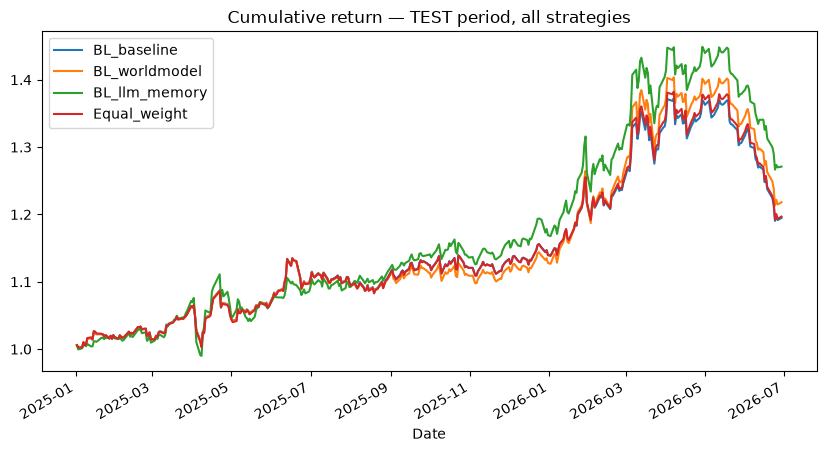

In [12]:
results2 = pd.concat([
    metrics(bt2["BL_baseline"],   "BL_baseline"),
    metrics(bt2["BL_worldmodel"], "BL_worldmodel"),
    metrics(bt2["BL_llm_memory"], "BL_llm_memory"),
    metrics(ew_rets,              "Equal_weight"),
], axis=1).round(4)
print(results2)

(1 + pd.DataFrame({k: v for k, v in bt2.items()} | {"Equal_weight": ew_rets})).cumprod().plot(
    figsize=(10, 5), title="Cumulative return — TEST period, all strategies")

### Save outputs

`bl_llm_memory_weights.csv` is the file the Safe RL step (`SAFE_RL_GUIDE.md`) has been waiting
on — one row per rebalance date, one column per asset, weights summing to 1. `bl_baseline_weights.csv`
is included too, since having both makes it trivial to run the ablation (with vs. without Step 5)
that `STEPS_4_5_6_GUIDE.md` calls out as the most informative remaining check.

In [13]:
for name in ["BL_baseline", "BL_worldmodel", "BL_llm_memory"]:
    wdf = pd.DataFrame(weight_log[name]).set_index("Date")
    wdf.to_csv(f"{name.lower()}_weights.csv")
    print(f"Saved: {name.lower()}_weights.csv", wdf.shape)

results2.to_csv("all_strategies_backtest_metrics.csv")
pd.DataFrame({k: v for k, v in bt2.items()} | {"Equal_weight": ew_rets}).to_csv("all_strategies_daily_returns.csv")
print("Saved: all_strategies_backtest_metrics.csv")
print("Saved: all_strategies_daily_returns.csv")

pd.DataFrame(weight_log["BL_llm_memory"]).set_index("Date").round(3)

Saved: bl_baseline_weights.csv (19, 4)
Saved: bl_worldmodel_weights.csv (19, 4)
Saved: bl_llm_memory_weights.csv (19, 4)
Saved: all_strategies_backtest_metrics.csv
Saved: all_strategies_daily_returns.csv


,EURUSD,GBPUSD,GOLD,OIL
Date,,,,
2025-01-02,0.571,0.168,0.164,0.097
2025-01-31,0.180,0.276,0.217,0.326
2025-02-28,0.309,0.019,0.410,0.262
2025-03-31,0.075,0.000,0.669,0.255
2025-04-30,0.516,0.000,0.421,0.062
2025-05-30,0.309,0.243,0.369,0.080
2025-06-30,0.160,0.236,0.322,0.282
2025-07-31,0.456,0.195,0.248,0.101
2025-08-29,0.455,0.164,0.252,0.129
